In [1]:
# Cell 1: Cài đặt thư viện (nếu cần)
!pip install -q -U transformers accelerate peft bitsandbytes datasets trl qwen-vl-utils rouge-score nltk bert_score torchao
!pip install -q -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install -q "torchao==0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 71.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.

In [2]:
import os
import torch
import numpy as np
import shutil
from datasets import load_dataset, Image, DatasetDict, Dataset
from transformers import (
    Qwen2_5_VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTConfig, SFTTrainer
from transformers import EarlyStoppingCallback
from qwen_vl_utils import process_vision_info
from sklearn.metrics import accuracy_score
from tqdm import tqdm

import matplotlib.pyplot as plt
import json
import string
import joblib
import re
import pandas as pd
from sklearn.model_selection import train_test_split

# Metrics
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import nltk
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score as bert_score

nltk.download('punkt', quiet=True)

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Skipping import of cpp extensions due to incompatible torch version 2.11.0+cu128 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


GPU available: True
GPU name: Tesla T4


In [3]:
BASE_DATA = "/kaggle/input/vietnam-landmark-mqa-dataset"
BASE_INPUT = "/kaggle/input/vietnam-landmark-mqa-dataset"
NAME_DIR = "landmark_vietnam_dataset_split"

In [4]:
# Đường dẫn gốc đến dataset (theo đường dẫn chuẩn của Kaggle)
# Thường dataset được mount tại /kaggle/input/<tên-dataset>
# Ở đây tên dataset là "landmark-mqa-dataset"
base_path = BASE_DATA

print("Kiểm tra đường dẫn:", base_path)
print("Có tồn tại?", os.path.exists(base_path))
print("Các thư mục con:")
if os.path.exists(base_path):
    for item in os.listdir(base_path):
        print(" -", item)
else:
    # Nếu không tìm thấy, thử đường dẫn có thêm "datasets"
    alt_path = BASE_DATA
    print(f"Thử đường dẫn thay thế: {alt_path}")
    if os.path.exists(alt_path):
        base_path = alt_path
        print("Đã tìm thấy tại:", base_path)
        for item in os.listdir(base_path):
            print(" -", item)
    else:
        print("Không tìm thấy dataset. Vui lòng kiểm tra lại tên dataset.")

Kiểm tra đường dẫn: /kaggle/input/vietnam-landmark-mqa-dataset
Có tồn tại? True
Các thư mục con:
 - test_vietnam_landmark.jsonl
 - val_vietnam_landmark.jsonl
 - train_vietnam_landmark.jsonl
 - landmark_vietnam_dataset_split


In [5]:
# Sau khi xác định base_path từ cell trên, chúng ta đặt lại các biến
# Giả sử base_path đã được gán đúng (từ cell trên)
# Nếu base_path chưa được định nghĩa, gán lại bằng tay
if 'base_path' not in dir():
    base_path = BASE_INPUT
    # Nếu không có, thử đường dẫn khác
    if not os.path.exists(base_path):
        base_path = BASE_DATA

# Tìm file json
json_file = None
for f in os.listdir(base_path):
    if f.endswith('.jsonl'):
        json_file = os.path.join(base_path, f)
        break
if json_file is None:
    # Có thể file nằm trong thư mục con
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.endswith('.jsonl'):
                json_file = os.path.join(root, f)
                break
        if json_file:
            break

if json_file is None:
    raise FileNotFoundError("Không tìm thấy file train.jsonl trong dataset")

print("Đã tìm thấy file json:", json_file)

# Tìm thư mục ảnh (thường là thư mục con chứa các folder số)
image_dir = None
for item in os.listdir(base_path):
    if os.path.isdir(os.path.join(base_path, item)):
        # Kiểm tra xem có folder số bên trong không
        subdir = os.path.join(base_path, item)
        if any(f.isdigit() for f in os.listdir(subdir)):
            image_dir = subdir
            break
if image_dir is None:
    # Có thể thư mục ảnh là "landmark_dataset"
    if os.path.exists(os.path.join(base_path, NAME_DIR)):
        image_dir = os.path.join(base_path, NAME_DIR)
    else:
        image_dir = base_path  # fallback

print("Thư mục ảnh:", image_dir)

Đã tìm thấy file json: /kaggle/input/vietnam-landmark-mqa-dataset/test_vietnam_landmark.jsonl
Thư mục ảnh: /kaggle/input/vietnam-landmark-mqa-dataset/landmark_vietnam_dataset_split


In [6]:
def load_jsonl_to_df(file_path):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

def prepare_hf_dataset(df, split_name):
    ds = Dataset.from_pandas(df)
    
    # Hàm fix path: Kết hợp IMAGE_BASE_DIR + split (train/val/test) + image_path trong JSON
    def fix_path(example):
        example["image_path"] = os.path.join(image_dir, split_name, example["image"])
        return example

    ds = ds.map(fix_path)
    # Cast cột image_path thành kiểu Image của HuggingFace để model Qwen đọc được
    ds = ds.cast_column("image_path", Image())
    return ds

# --- THỰC THI LOAD 3 TẬP ---

# 1. Load Train (Đã bao gồm ảnh Augment vì lấy từ folder train)
df_train = load_jsonl_to_df(os.path.join(BASE_DATA, "train_vietnam_landmark.jsonl"))
train_dataset = prepare_hf_dataset(df_train, "train")

# 2. Load Val (Tập sạch)
df_val = load_jsonl_to_df(os.path.join(BASE_DATA, "val_vietnam_landmark.jsonl"))
val_dataset = prepare_hf_dataset(df_val, "val")

# 3. Load Test (Tập sạch)
df_test = load_jsonl_to_df(os.path.join(BASE_DATA, "test_vietnam_landmark.jsonl"))
test_dataset = prepare_hf_dataset(df_test, "test")

print(f"Train: {len(train_dataset)}")
print(f"Val: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

Map:   0%|          | 0/4389 [00:00<?, ? examples/s]

Map:   0%|          | 0/359 [00:00<?, ? examples/s]

Map:   0%|          | 0/395 [00:00<?, ? examples/s]

Train: 4389
Val: 359
Test: 395


In [7]:
# import torch
# from PIL import Image
# import math

# PATCH_SIZE = 28
# TARGET_MAX_SIZE = 504  # 28 * 18 → ~324 tokens (ổn định, nhẹ VRAM)

# def pad_to_square(img):
#     w, h = img.size
#     size = max(w, h)
#     new_img = Image.new("RGB", (size, size), (0,0,0))
#     new_img.paste(img, ((size - w)//2, (size - h)//2))
#     return new_img

# def smart_resize_by_tokens(img, target_tokens=196):
#     w, h = img.size

#     # số patch theo 1 chiều (sqrt token)
#     target_grid = int(math.sqrt(target_tokens))

#     # scale theo cạnh dài
#     scale = (target_grid * PATCH_SIZE) / max(w, h)
#     scale = min(scale, 1.0)  # ❗ không upscale

#     new_w = int(w * scale)
#     new_h = int(h * scale)

#     # snap về bội số 28
#     new_w = max(PATCH_SIZE, (new_w // PATCH_SIZE) * PATCH_SIZE)
#     new_h = max(PATCH_SIZE, (new_h // PATCH_SIZE) * PATCH_SIZE)

#     return img.resize((new_w, new_h), Image.Resampling.LANCZOS)

In [8]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

In [9]:
SYSTEM_PROMPT = """### ROLE
You are a specialized Landmark Recognition Expert. Your ONLY task is to identify landmarks from images.

### STRICT OUTPUT RULE (CRITICAL)
Your response MUST ALWAYS start with the exact phrase: "Based on the visual features, this is ". 
DO NOT use any other introduction. DO NOT explain. DO NOT add conversational filler.

- Format: Based on the visual features, this is [Exact Name of Landmark], [City/Location]
- If you cannot identify it: Outside scope
- If it is a generic object: Outside scope

### GUIDELINES
1. FAMOUS STREETS/SQUARES: Treat famous urban areas (e.g., Ba Dinh Square, Nguyen Hue Walking Street) as landmarks.
2. SPECIFICITY: If a landmark is inside a square, name the square if the image shows the broader area.
3. OUTSIDE SCOPE: Respond "Outside scope" for coding, math, general chat, or non-landmark images.
FEW-SHOT EXAMPLES:
User: (Image of a street in Saigon)
Assistant: Based on the visual features, this is Pham Ngu Lao Street, Ho Chi Minh City

User: (Image of a cat)
Assistant: Outside scope

User: (Text) Write a Python script for sorting.
Assistant: Outside scope
"""

In [10]:
from PIL import Image as PILImage 
import math

# SYSTEM_PROMPT = """You are a highly specialized AI assistant focused exclusively on landmarks and tourist attractions.

# CORE MISSION:
# 1. Identify historical sites, architectural monuments, landscapes, or cultural attractions from provided images OR text descriptions.
# 2. Provide information ONLY related to Landmarks.

# STRICT OPERATING RULES:
# - LANDMARK IN IMAGES: If an image is provided and contains a landmark, you MUST start your response exactly with: "Based on the visual features, this is [Landmark Name]".
# - LANDMARK IN TEXT: If the user asks about a specific landmark via text (without an image), provide the information directly but keep it focused strictly on the landmark's history, location, and significance.
# - NON-LANDMARK CONTENT: If the image OR the text query does not relate to a recognizable landmark (e.g., animals, common objects, math, coding, general knowledge), you MUST respond exactly with: "I'm sorry, I am only trained to provide information about Landmarks. This request is outside my scope of support."
# - OUT-OF-DOMAIN QUERIES: Politely decline any requests to perform tasks like solving equations, writing code, or discussing general topics unrelated to travel and landmarks.
# - NO GUESSING: If the image is unclear or the text description is too vague to identify a specific landmark, state that you cannot identify it clearly.

# Always maintain a professional and helpful tone within the landmark domain."""



class MultimodalModel:
    def __init__(self, model, processor, device="cuda"):
        self.model = model
        self.processor = processor
        self.device = device
        
        if hasattr(self.processor, "tokenizer"):
            self.processor.tokenizer.padding_side = "left"
        else:
            # Đối với một số bản transformers cũ hơn
            self.processor.padding_side = "left"
        
        self.model.eval()

    def pad_to_square(self, img):
        w, h = img.size
        size = max(w, h)
        new_img = PILImage.new("RGB", (size, size), (0, 0, 0))
        new_img.paste(img, ((size - w) // 2, (size - h) // 2))
        return new_img

    def smart_resize_by_tokens(self, img, target_tokens=196, patch_size = 28):
        w, h = img.size
        target_grid = int(math.sqrt(target_tokens))
        
        scale = (target_grid * patch_size) / max(w, h)
        scale = min(scale, 1.0)
        
        new_w = int(w * scale)
        new_h = int(h * scale)
        
        new_w = max(patch_size, (new_w // patch_size) * patch_size)
        new_h = max(patch_size, (new_h // patch_size) * patch_size)
        
        try:
            resample_filter = PILImage.Resampling.LANCZOS
        except AttributeError:
            resample_filter = PILImage.LANCZOS
            
        return img.resize((new_w, new_h), resample_filter)

    def preprocess_image(self, image_path):
        # 1. Xử lý load ảnh
        if isinstance(image_path, str):
            image = PILImage.open(image_path).convert("RGB")
        else:
            image = image_path.convert("RGB")
            
        # 2. Gọi các hàm bổ trợ thông qua self.
        image = self.pad_to_square(image)
        image = self.smart_resize_by_tokens(image)
        return image

    def predict(self, prompt, image_path=None, system_prompt=SYSTEM_PROMPT):
        content = []
        
        if image_path:
            processed_image = self.preprocess_image(image_path)
            content.append({"type": "image", "image": processed_image})
            
        content.append({"type": "text", "text": prompt})

        messages = [
            {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
            {"role": "user", "content": content}
        ]

        # 2. Xử lý Template và Vision Info
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        
        # Chỉ xử lý vision info
        image_inputs = None
        video_inputs = None
        if image_path:
            from qwen_vl_utils import process_vision_info
            image_inputs, video_inputs = process_vision_info(messages)

        # 3. Chuẩn bị Inputs cho model
        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(self.device)

        # Ép kiểu bfloat16 nếu có pixel values (dành cho GPU hỗ trợ)
        if "pixel_values" in inputs:
            inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

        # 4. Sinh văn bản (Inference)
        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, max_new_tokens=128)
        
        # 5. Giải mã và cắt bỏ phần prompt cũ
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        output_text = self.processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0]
        
        return output_text


    def predict_batch(self, prompts, image_paths=None, system_prompt=SYSTEM_PROMPT):
        """
        prompts: List[str]
        image_paths: List[str hoặc PIL Image] hoặc None
        """
        batch_size = len(prompts)
        all_messages = []
        
        for i in range(batch_size):
            content = []
            if image_paths and image_paths[i]:
                processed_image = self.preprocess_image(image_paths[i])
                content.append({"type": "image", "image": processed_image})
            
            content.append({"type": "text", "text": prompts[i]})
            
            all_messages.append([
                {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
                {"role": "user", "content": content}
            ])

        # 1. Apply template cho cả batch
        texts = [self.processor.apply_chat_template(msg, tokenize=False, add_generation_prompt=True) for msg in all_messages]
        
        # 2. Xử lý Vision Info cho cả batch
        image_inputs, video_inputs = process_vision_info(all_messages)

        # 3. Tokenize và Padding (Quan trọng: padding=True giúp các câu dài ngắn khác nhau khớp vào 1 tensor)
        inputs = self.processor(
            text=texts,
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        ).to(self.device)

        if "pixel_values" in inputs:
            inputs["pixel_values"] = inputs["pixel_values"].to(torch.bfloat16)

        # 4. Generate
        with torch.no_grad():
            generated_ids = self.model.generate(**inputs, max_new_tokens=128)
        
        # 5. Cắt và Decode
        # Lưu ý: inputs.input_ids.shape[1] là độ dài của prompt dài nhất trong batch
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        
        output_texts = self.processor.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )
        
        return output_texts

In [11]:
def normalize_answer(s):
    return s.lower().strip()

def vqa_accuracy(pred, ref):
    """
    ref có thể là:
    - string (single answer)
    - list answers (multi annotators)
    """
    pred = normalize_answer(pred)

    if isinstance(ref, list):
        ref = [normalize_answer(r) for r in ref]
        count = Counter(ref)
        return min(count[pred] / 3, 1.0)
    else:
        return float(pred == normalize_answer(ref))

def get_ground_truth(example):
    # messages[2] là assistant, content[0] là text chứa câu trả lời
    return example["messages"][2]["content"][0]["text"].strip()

In [12]:
def evaluate_model(multi_model, dataset, system_prompt = SYSTEM_PROMPT):
    multi_model.model.eval()
    
    predictions = []
    references = []
    
    for ex in tqdm(dataset, desc="Evaluating"):

        image_input = ex.get("image_path") # Có thể là đường dẫn hoặc PIL Image
        question = ex["messages"][1]["content"][1]["text"]
        true_answer = get_ground_truth(ex)

        answer = multi_model.predict(
            prompt=question, 
            image_path=image_input, 
            system_prompt=system_prompt
        )
        

        # messages = [
        #     {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        #     {"role": "user", "content": [
        #         {"type": "image", "image": image},
        #         {"type": "text", "text": question}
        #     ]}
        # ]
        #
        # text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        # image_inputs, video_inputs = process_vision_info(messages)
        # inputs = processor(
        #     text=[text],
        #     images=image_inputs,
        #     videos=video_inputs,
        #     padding=True,
        #     return_tensors="pt",
        #     max_pixels=392 * 392,
        #     min_pixels = 392 * 392,
        # ).to(device)

        # with torch.no_grad():
        #     generated_ids = model.generate(**inputs, max_new_tokens=128)
        # generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
        # answer = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

        predictions.append(answer)
        references.append(true_answer)

    # METRICS
    # Exact Match (đã normalize)
    exact_match = np.mean([
        normalize_answer(p) == normalize_answer(r if not isinstance(r, list) else r[0])
        for p, r in zip(predictions, references)
    ])

    # 2. VQA Accuracy
    vqa_acc = np.mean([
        vqa_accuracy(p, r) for p, r in zip(predictions, references)
    ])

    # 3. BLEU Score
    smooth = SmoothingFunction().method1
    bleu_scores = [
        sentence_bleu([ (r if isinstance(r, str) else r[0]).split() ],
                      p.split(),
                      smoothing_function=smooth)
        for p, r in zip(predictions, references)
    ]

    # 4. ROUGE-L
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rougeL = []

    for p, r in zip(predictions, references):
        ref = r if isinstance(r, str) else r[0]
        scores = scorer.score(ref, p)
        rougeL.append(scores['rougeL'].fmeasure)

    # 5. BERTScore
    refs_flat = [r if isinstance(r, str) else r[0] for r in references]

    P, R, F1 = bert_score(predictions, refs_flat, lang="en", verbose=False)

    return {
        "exact_match": exact_match,
        "vqa_accuracy": vqa_acc,
        "bleu": np.mean(bleu_scores),
        "rougeL": np.mean(rougeL),
        "bert_score_f1": F1.mean().item(),
        "predictions": predictions,
        "references": references
    }

In [13]:
def extract_landmark_name(text):
    # Tìm phần văn bản đứng sau cụm "this is" hoặc "is"
    match = re.search(r"is\s+(.*)", text, re.IGNORECASE)
    if match:
        name = match.group(1).strip()
        # Loại bỏ dấu chấm ở cuối và các ngoặc vuông/tròn nếu có
        name = re.sub(r"[\.\[\]\(\)]", "", name)
        return name.strip()
    return text.strip()

def final_normalize(text):
    text = text.lower()
    # Loại bỏ dấu câu (comma, period, etc.)
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Loại bỏ khoảng trắng thừa
    return " ".join(text.split())

In [14]:
def evaluate_batch_model(multi_model, dataset, batch_size=4, system_prompt=SYSTEM_PROMPT):
    multi_model.model.eval()
    predictions = []
    references = []
    
    for i in tqdm(range(0, len(dataset), batch_size), desc="Evaluating"):
        # Lấy batch dưới dạng dict of lists
        batch = dataset[i : i + batch_size]
        
        # 1. Lấy thẳng list từ key (không cần dùng list comprehension phức tạp)
        batch_images = batch["image_path"]
        
        # 2. Với messages, chúng ta map để lấy câu hỏi
        # Cấu trúc: messages[1] (user) -> content[1] (text)
        batch_questions = [msg[1]["content"][1]["text"] for msg in batch["messages"]]
        
        # 3. Lấy Ground Truth (Assistant trả lời)
        # Sửa lại hàm get_ground_truth cho phù hợp với cấu trúc message lẻ
        #batch_references = [msg[2]["content"][0]["text"].strip() for msg in batch["messages"]]

        batch_references = [
            msg[2]["content"][0]["text"].split("|")[-1].replace("Answer:", "").strip() 
            for msg in batch["messages"]
        ]

        # batch_references = [
        #     extract_landmark_name(msg[2]["content"][0]["text"].split("|")[-1].replace("Answer:", "").strip()) 
        #     for msg in batch["messages"]
        # ]

        # 4. Gọi hàm predict_batch của Class
        batch_outputs = multi_model.predict_batch(
            prompts=batch_questions,
            image_paths=batch_images,
            system_prompt=system_prompt
        )

        predictions.extend([ans.strip() for ans in batch_outputs])
        references.extend(batch_references)


    clean_preds = [final_normalize(extract_landmark_name(p)) for p in predictions]
    clean_refs = [final_normalize(extract_landmark_name(r)) for r in references]
    
    # METRIC
    # 1. Exact Match
    exact_match = np.mean([p == r for p, r in zip(clean_preds, clean_refs)])

    # 2. VQA Accuracy
    vqa_acc = np.mean([vqa_accuracy(p, r) for p, r in zip(clean_preds, clean_refs)])

    # 3. BLEU Score
    smooth = SmoothingFunction().method1
    bleu_scores = [
        sentence_bleu([ (r if isinstance(r, str) else r[0]).split() ],
                      p.split(),
                      smoothing_function=smooth)
        for p, r in zip(predictions, references)
    ]

    # 4. ROUGE-L
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rougeL = []

    for p, r in zip(predictions, references):
        ref = r if isinstance(r, str) else r[0]
        scores = scorer.score(ref, p)
        rougeL.append(scores['rougeL'].fmeasure)

    # 5. BERTScore
    refs_flat = [r if isinstance(r, str) else r[0] for r in clean_refs]

    P, R, F1 = bert_score(clean_preds, refs_flat, lang="en", verbose=False)

    return {
        "exact_match": exact_match,
        "vqa_accuracy": vqa_acc,
        "bleu": np.mean(bleu_scores),
        "rougeL": np.mean(rougeL),
        "bert_score_f1": F1.mean().item(),
        "predictions": predictions,
        "references": references
    }

In [15]:
small_test_dataset = test_dataset.shuffle(seed=42)

## Base Model

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load base model
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

# from peft import PeftModel

# lora_path_base = "/kaggle/input/datasets/kimngntrn510/finetuned-landmark-qwen-vl"

# base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
#     model_id,
#     torch_dtype=torch.bfloat16,
#     device_map="auto"
# )

# processor = AutoProcessor.from_pretrained(model_id)

# base_model = PeftModel.from_pretrained(base_model, lora_path_base)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

chat_template.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
multi_model_base = MultimodalModel(base_model, processor)
print("Đánh giá base model trên test set...")
base_results = evaluate_batch_model(multi_model_base, small_test_dataset)

Đánh giá base model trên test set...



Evaluating: 100%|██████████| 99/99 [19:10<00:00, 11.62s/it]


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
joblib.dump(base_results, 'eval_base_result.pkl')
# base_results = joblib.load("/kaggle/input/datasets/kimngntrn510/eval-landmark-vietnam-result/eval_base_result.pkl")

['eval_base_result.pkl']

In [19]:
print("\n=== Kết quả base model ===")
for k in ['exact_match', 'vqa_accuracy', 'bleu', 'rougeL', 'bert_score_f1']:
    print(f"{k} : {base_results[k]:.4f}")


=== Kết quả base model ===
exact_match : 0.0101
vqa_accuracy : 0.0101
bleu : 0.5504
rougeL : 0.6939
bert_score_f1 : 0.8404


## Fine-tuned Model

In [20]:
lora_path = "/kaggle/input/datasets/kimngntrn510/qwen-checkpoint-2196-vietnam"

In [21]:
# Load model đã fine-tune (từ checkpoint tốt nhất)
from peft import PeftModel

ft_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)

ft_model = PeftModel.from_pretrained(ft_model, lora_path)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [22]:
multi_model_ft = MultimodalModel(ft_model, processor)

print("Đánh giá fine-tuned model trên test set...")
ft_results = evaluate_batch_model(multi_model_ft, small_test_dataset)

Đánh giá fine-tuned model trên test set...


Evaluating: 100%|██████████| 99/99 [20:15<00:00, 12.28s/it]


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [23]:
joblib.dump(ft_results, 'eval_ft_results_.pkl')
# ft_results = joblib.load("/kaggle/input/datasets/kimngntrn510/eval-landmark-vietnam-result/eval_ft_results.pkl")

['eval_ft_results_.pkl']

In [24]:
print("\n=== Kết quả fine-tuned model ===")
for k in ['exact_match', 'vqa_accuracy', 'bleu', 'rougeL', 'bert_score_f1']:
    print(f"{k} : {ft_results[k]:.4f}")


=== Kết quả fine-tuned model ===
exact_match : 0.0127
vqa_accuracy : 0.0127
bleu : 0.5516
rougeL : 0.7148
bert_score_f1 : 0.8541


In [25]:
def token_f1(pred, ref):
    pred_tokens = set(pred.lower().split())
    ref_tokens = set(ref.lower().split())
    if not pred_tokens or not ref_tokens:
        return 0.0
    intersection = pred_tokens.intersection(ref_tokens)
    precision = len(intersection) / len(pred_tokens)
    recall = len(intersection) / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

base_token_f1 = np.mean([token_f1(p, r) for p, r in zip(base_results['predictions'], base_results['references'])])
ft_token_f1 = np.mean([token_f1(p, r) for p, r in zip(ft_results['predictions'], ft_results['references'])])

In [26]:
print("\n" + "="*60)
print("SO SÁNH CẢI THIỆN")
print("="*60)
print(f"{'Metric':<15} {'Base':<12} {'Fine-tuned':<12} {'Change':<12}")
print("-"*60)
# Các chỉ số đã có trong kết quả
for m in ['exact_match', 'vqa_accuracy', 'bleu', 'rougeL', 'bert_score_f1']:
    base_val = base_results[m]
    ft_val = ft_results[m]
    change = ft_val - base_val
    print(f"{m:<15} {base_val:<12.4f} {ft_val:<12.4f} {change:+.4f}")
# Thêm token F1
print(f"{'token_f1':<15} {base_token_f1:<12.4f} {ft_token_f1:<12.4f} {ft_token_f1 - base_token_f1:+.4f}")


SO SÁNH CẢI THIỆN
Metric          Base         Fine-tuned   Change      
------------------------------------------------------------
exact_match     0.0101       0.0127       +0.0025
vqa_accuracy    0.0101       0.0127       +0.0025
bleu            0.5504       0.5516       +0.0012
rougeL          0.6939       0.7148       +0.0210
bert_score_f1   0.8404       0.8541       +0.0137
token_f1        0.6726       0.6872       +0.0146



=== Một số mẫu sai (base model) ===


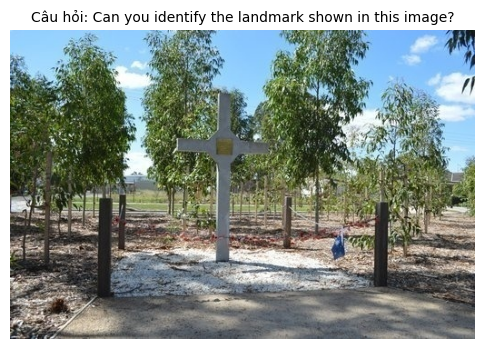

Mẫu 0:
  Dự đoán (base): Based on the visual features, this is Anzac Memorial, Brisbane
  Đúng         : Based on the visual features, this is Long Tan Cross.
--------------------------------------------------


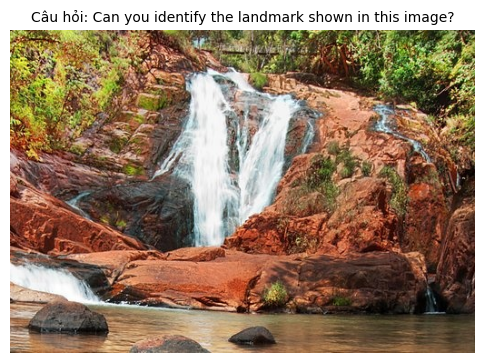

Mẫu 1:
  Dự đoán (base): Based on the visual features, this is Florence Falls, Queensland
  Đúng         : Based on the visual features, this is Hang Cop Waterfall.
--------------------------------------------------


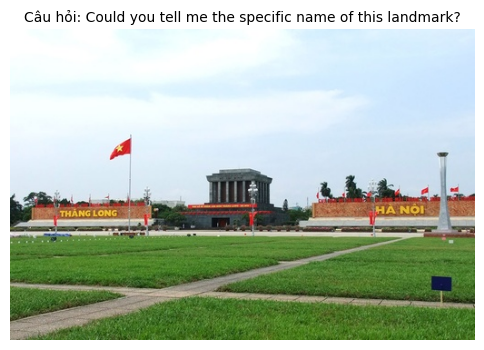

Mẫu 2:
  Dự đoán (base): Based on the visual features, this is Ho Chi Minh Mausoleum, Hanoi
  Đúng         : Based on the visual features, this is Ba Đình Square, Hanoi.
--------------------------------------------------


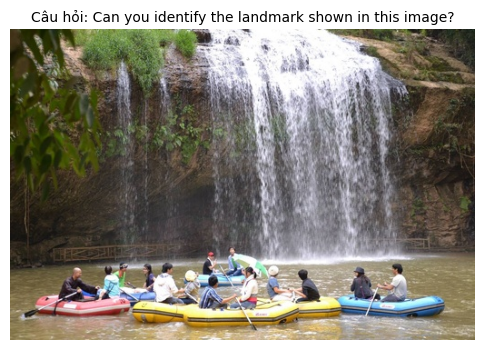

Mẫu 3:
  Dự đoán (base): Based on the visual features, this is Huangguoshu Waterfall, Guizhou Province
  Đúng         : Based on the visual features, this is Prenn Waterfall.
--------------------------------------------------


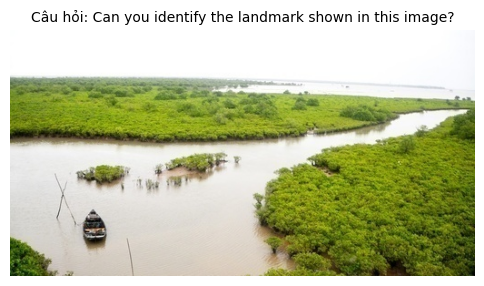

Mẫu 4:
  Dự đoán (base): Based on the visual features, this is a mangrove forest, outside scope.
  Đúng         : Based on the visual features, this is Xuan Thuy National Park.
--------------------------------------------------

=== Một số mẫu sai (fine-tuned model) ===


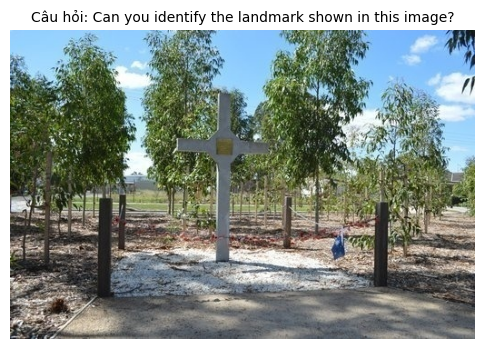

Mẫu 0:
  Dự đoán (fine-tuned): Based on the visual features, this is the Cross of Sacrifice, Long Binh, Vietnam
  Đúng               : Based on the visual features, this is Long Tan Cross.
--------------------------------------------------


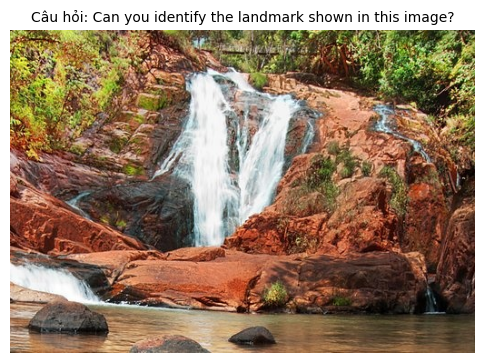

Mẫu 1:
  Dự đoán (fine-tuned): Based on the visual features, this is Banyumala Waterfall, Bali
  Đúng               : Based on the visual features, this is Hang Cop Waterfall.
--------------------------------------------------


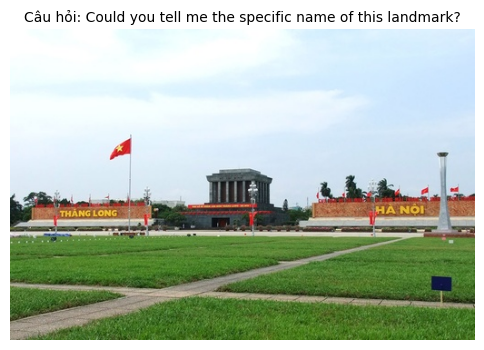

Mẫu 2:
  Dự đoán (fine-tuned): Based on the visual features, this is Ho Chi Minh Mausoleum, Hanoi
  Đúng               : Based on the visual features, this is Ba Đình Square, Hanoi.
--------------------------------------------------


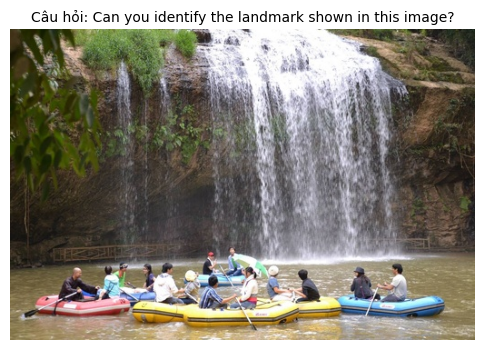

Mẫu 3:
  Dự đoán (fine-tuned): Based on the visual features, this is Tad Ky Waterfall, Phu Tho Province
  Đúng               : Based on the visual features, this is Prenn Waterfall.
--------------------------------------------------


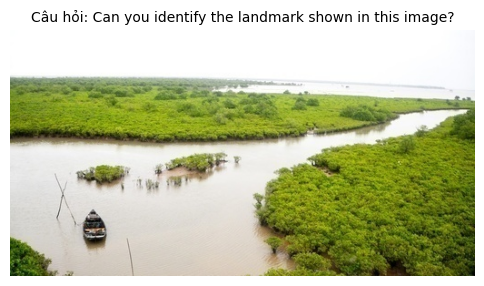

Mẫu 4:
  Dự đoán (fine-tuned): Based on the visual features, this is Mekong Delta, Vietnam
  Đúng               : Based on the visual features, this is Xuan Thuy National Park.
--------------------------------------------------


In [27]:
import matplotlib.pyplot as plt

print("\n=== Một số mẫu sai (base model) ===")
count = 0
for i, (pred, ref) in enumerate(zip(base_results['predictions'], base_results['references'])):
    if pred != ref:
        sample = small_test_dataset[i]
        image = sample["image_path"]
        question = sample["messages"][1]["content"][1]["text"]
        
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Câu hỏi: {question}", fontsize=10)
        plt.show()
        
        print(f"Mẫu {i}:")
        print(f"  Dự đoán (base): {pred}")
        print(f"  Đúng         : {ref}")   # ref từ base_results đã là câu trả lời đúng
        print("-" * 50)
        count += 1
        if count >= 5:
            break

print("\n=== Một số mẫu sai (fine-tuned model) ===")
count = 0
for i, (pred, ref) in enumerate(zip(ft_results['predictions'], ft_results['references'])):
    if pred != ref:
        sample = small_test_dataset[i]
        image = sample["image_path"]
        question = sample["messages"][1]["content"][1]["text"]
        
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Câu hỏi: {question}", fontsize=10)
        plt.show()
        
        print(f"Mẫu {i}:")
        print(f"  Dự đoán (fine-tuned): {pred}")
        print(f"  Đúng               : {ref}")
        print("-" * 50)
        count += 1
        if count >= 5:
            break

## ANALYSIS WITH BERT SCORE

In [28]:
def calculate_bert_score(predictions, references):
    # flatten reference (nếu là list)
    refs_flat = [r if isinstance(r, str) else r[0] for r in references]
    
    # tính BERTScore per sample
    P, R, F1 = bert_score(predictions, refs_flat, lang="en", verbose=False)
    bert_f1_scores = F1.tolist()

    return bert_f1_scores

In [29]:
def sample_bert_score(results, ascending, dataset):
    predictions = results["predictions"]
    references = results["references"]
    
    bert_f1_scores = calculate_bert_score(predictions, references)
    
    # sort index theo score giảm dần
    sorted_idx = sorted(range(len(bert_f1_scores)), key=lambda i: bert_f1_scores[i], reverse=ascending)
    
    # in top 5
    for i in sorted_idx[:10]:
        sample = dataset[i]
        image = sample["image_path"]
        question = sample["messages"][1]["content"][1]["text"]
    
        pred = predictions[i]
        ref = references[i]
        score = bert_f1_scores[i]
    
        # # show image
        # plt.figure(figsize=(6,6))
        # plt.imshow(image)
        # plt.axis("off")
        # plt.title(f"Q: {question}", fontsize=10)
        # plt.show()
    
        print(f"Mẫu {i}")
        print(f"  BERTScore : {score:.4f}")
        print(f"  GT        : {ref}")
        print(f"  Pred      : {pred}")
        print("-"*60)

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


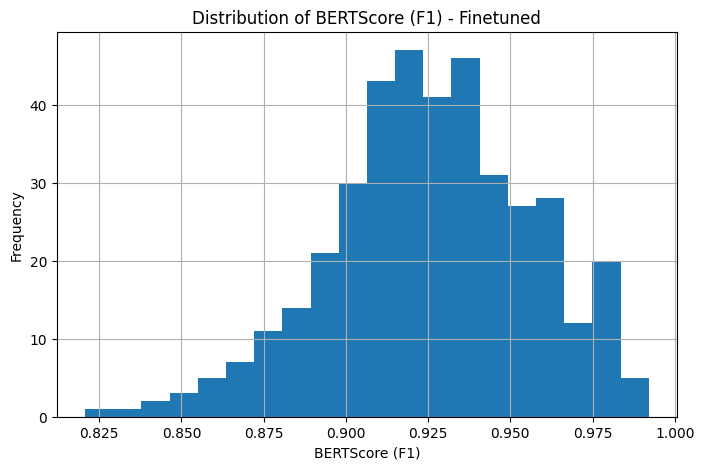

In [30]:
bert_score_ft = calculate_bert_score(ft_results['predictions'], ft_results['references'])

plt.figure(figsize=(8, 5))

plt.hist(bert_score_ft, bins=20)

plt.xlabel("BERTScore (F1)")
plt.ylabel("Frequency")
plt.title("Distribution of BERTScore (F1) - Finetuned")

plt.grid(True)

plt.show()

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


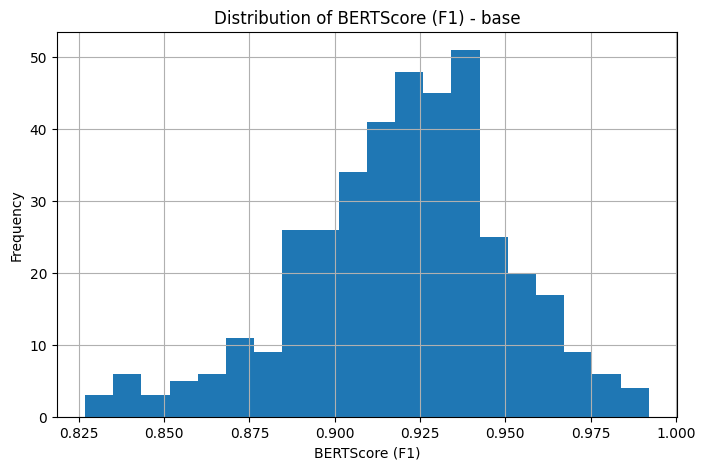

In [31]:
bert_score_base = calculate_bert_score(base_results['predictions'], base_results['references'])

plt.figure(figsize=(8, 5))

plt.hist(bert_score_base, bins=20)

plt.xlabel("BERTScore (F1)")
plt.ylabel("Frequency")
plt.title("Distribution of BERTScore (F1) - base")

plt.grid(True)

plt.show()

In [32]:
from bert_score import score as bert_score
import matplotlib.pyplot as plt

print("\n=== MẪU BERT SCORE CAO FINETUNED ===\n")

sample_bert_score(ft_results, ascending=True, dataset=small_test_dataset)


=== MẪU BERT SCORE CAO FINETUNED ===



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mẫu 124
  BERTScore : 0.9921
  GT        : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City.
  Pred      : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City
------------------------------------------------------------
Mẫu 137
  BERTScore : 0.9921
  GT        : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City.
  Pred      : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City
------------------------------------------------------------
Mẫu 138
  BERTScore : 0.9907
  GT        : Based on the visual features, this is Presidential Palace, Hanoi.
  Pred      : Based on the visual features, this is Presidential Palace, Hanoi
------------------------------------------------------------
Mẫu 210
  BERTScore : 0.9879
  GT        : Based on the visual features, this is Cathedral of Christ the King (Nha Trang).
  Pred      : Based on the visual features, this is Cathedral of Christ the King, Nha Trang
------

In [33]:
print("\n=== MẪU BERT SCORE CAO BASE ===\n")

sample_bert_score(base_results, ascending=True, dataset=small_test_dataset)


=== MẪU BERT SCORE CAO BASE ===



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mẫu 124
  BERTScore : 0.9921
  GT        : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City.
  Pred      : Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City
------------------------------------------------------------
Mẫu 138
  BERTScore : 0.9907
  GT        : Based on the visual features, this is Presidential Palace, Hanoi.
  Pred      : Based on the visual features, this is Presidential Palace, Hanoi
------------------------------------------------------------
Mẫu 210
  BERTScore : 0.9879
  GT        : Based on the visual features, this is Cathedral of Christ the King (Nha Trang).
  Pred      : Based on the visual features, this is Cathedral of Christ the King, Nha Trang
------------------------------------------------------------
Mẫu 204
  BERTScore : 0.9865
  GT        : Based on the visual features, this is West Lake (Hanoi).
  Pred      : Based on the visual features, this is West Lake, Hanoi
-----------------------------------------

In [34]:
print("\n=== MẪU BERT SCORE THẤP ===\n")

sample_bert_score(ft_results, ascending=False, dataset=small_test_dataset)


=== MẪU BERT SCORE THẤP ===



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mẫu 276
  BERTScore : 0.8207
  GT        : Based on the visual features, this is Đan Viện Thánh Mẫu Châu Sơn Đơn Dương.
  Pred      : Based on the visual features, this is Notre-Dame Cathedral, Hanoi
------------------------------------------------------------
Mẫu 125
  BERTScore : 0.8370
  GT        : Based on the visual features, this is Tram Chim National Park.
  Pred      : Outside scope
------------------------------------------------------------
Mẫu 342
  BERTScore : 0.8402
  GT        : Based on the visual features, this is Miếu Nhị Phủ.
  Pred      : Based on the visual features, this is Sheng An Temple, Kaohsiung
------------------------------------------------------------
Mẫu 392
  BERTScore : 0.8433
  GT        : Based on the visual features, this is Thánh thất Đa Phước.
  Pred      : Based on the visual features, this is Cathedral of the Holy Trinity, Dalat, Vietnam
------------------------------------------------------------
Mẫu 262
  BERTScore : 0.8464
  GT        : Based

In [35]:
print("\n=== MẪU BERT SCORE THẤP ===\n")

sample_bert_score(base_results, ascending=False, dataset=small_test_dataset)


=== MẪU BERT SCORE THẤP ===



Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mẫu 276
  BERTScore : 0.8268
  GT        : Based on the visual features, this is Đan Viện Thánh Mẫu Châu Sơn Đơn Dương.
  Pred      : Based on the visual features, this is St. Joseph's Cathedral, Hanoi
------------------------------------------------------------
Mẫu 392
  BERTScore : 0.8316
  GT        : Based on the visual features, this is Thánh thất Đa Phước.
  Pred      : Based on the visual features, this is the Church of the Holy Sepulcher, Jerusalem
------------------------------------------------------------
Mẫu 144
  BERTScore : 0.8337
  GT        : Based on the visual features, this is Đền Mẫu Âu Cơ.
  Pred      : Based on the visual features, this is Dai Nam Long An University, Long An Province
------------------------------------------------------------
Mẫu 125
  BERTScore : 0.8370
  GT        : Based on the visual features, this is Tram Chim National Park.
  Pred      : Outside scope
------------------------------------------------------------
Mẫu 87
  BERTScore : 0.8410
 

In [36]:
base_scores = bert_score_base
ft_scores = bert_score_ft

In [37]:
low_base_indices = [276, 392, 144, 125, 87, 383, 262, 342, 371, 182]

print(f"{'='*30} SO SÁNH CHI TIẾT BASE vs FINE-TUNED {'='*30}\n")

for idx in low_base_indices:
    gt = ft_results['references'][idx]
    base_p = base_results['predictions'][idx]
    ft_p = ft_results['predictions'][idx]
    
    # Lấy điểm từ list score ông đã tính ở các bước trước
    b_s = base_scores[idx]
    f_s = ft_scores[idx]
    gap = f_s - b_s

    print(f"Mẫu số {idx}:")
    print(f"  [GT]   : {gt}")
    print(f"  [Base] : {base_p} (Score: {b_s:.4f})")
    print(f"  [FT]   : {ft_p} (Score: {f_s:.4f})")
    
    # In ra nhận xét nhanh
    status = "CẢI THIỆN TỐT" if gap > 0.02 else ("GIẢM ĐIỂM" if gap < -0.02 else "TƯƠNG ĐƯƠNG")
    print(f"  => Kết quả: {status} (Chênh lệch: {gap:+.4f})")
    print("-" * 85)

============================== SO SÁNH CHI TIẾT BASE vs FINE-TUNED ==============================

Mẫu số 276:
  [GT]   : Based on the visual features, this is Đan Viện Thánh Mẫu Châu Sơn Đơn Dương.
  [Base] : Based on the visual features, this is St. Joseph's Cathedral, Hanoi (Score: 0.8268)
  [FT]   : Based on the visual features, this is Notre-Dame Cathedral, Hanoi (Score: 0.8207)
  => Kết quả: TƯƠNG ĐƯƠNG (Chênh lệch: -0.0061)
-------------------------------------------------------------------------------------
Mẫu số 392:
  [GT]   : Based on the visual features, this is Thánh thất Đa Phước.
  [Base] : Based on the visual features, this is the Church of the Holy Sepulcher, Jerusalem (Score: 0.8316)
  [FT]   : Based on the visual features, this is Cathedral of the Holy Trinity, Dalat, Vietnam (Score: 0.8433)
  => Kết quả: TƯƠNG ĐƯƠNG (Chênh lệch: +0.0117)
-------------------------------------------------------------------------------------
Mẫu số 144:
  [GT]   : Based on the visual 

In [38]:
def get_single_result(results, i):
    return {
        "prediction": results["predictions"][i],
        "reference": results["references"][i],
        # Bạn có thể bổ sung thêm các metric khác nếu kết quả đã được lưu sẵn
    }

In [39]:

analysis_list = []

for i in range(len(test_dataset)):
    # Lấy thông tin input từ dataset (thay 'image' hoặc 'prompt' tùy theo tên cột của bạn)
    # Nếu là ảnh, bạn có thể lấy path: test_dataset[i]['image_path']
    input_info = small_test_dataset[i]['image_path']
    
    analysis_list.append({
        'id': i,
        'input': input_info,
        'ref': ft_results['references'][i],
        'base_pred': base_results['predictions'][i],
        'ft_pred': ft_results['predictions'][i],
        'base_score': base_scores[i],
        'ft_score': ft_scores[i],
        'gap': ft_scores[i] - base_scores[i]
    })

# 3. Lọc các mẫu: FT điểm cao (> 0.9) và Base điểm thấp hơn đáng kể (gap > 0.15)
# Bạn có thể điều chỉnh con số này tùy theo phân phối điểm của bạn
top_improvements = [
    item for item in analysis_list 
    if item['ft_score'] > 0.85 and item['gap'] > 0.05
]

# Sắp xếp theo mức độ cải thiện giảm dần
top_improvements = sorted(top_improvements, key=lambda x: x['ft_score'], reverse=True)

# 4. In kết quả để đưa vào báo cáo
print(f"{'='*20} CÁC MẪU CẢI THIỆN RÕ RỆT (DÙNG CHO BÁO CÁO) {'='*20}\n")

for i, res in enumerate(top_improvements[:20]): # Lấy top 10 ví dụ điển hình nhất
    print(f"Ví dụ {i+1} (Index: {res['id']}):")
    print(f"  - Input/Image: {res['input']}")
    print(f"  - Ground Truth: {res['ref']}")
    print(f"  - Base Model  : \"{res['base_pred']}\" (Score: {res['base_score']:.4f})")
    print(f"  - FT Model    : \"{res['ft_pred']}\" (Score: {res['ft_score']:.4f})")
    print(f"  - Improvement : +{res['gap']:.4f}")
    print("-" * 80)

==================== CÁC MẪU CẢI THIỆN RÕ RỆT (DÙNG CHO BÁO CÁO) ====================

Ví dụ 1 (Index: 137):
  - Input/Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x341 at 0x7BAA154D1D90>
  - Ground Truth: Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City.
  - Base Model  : "Based on the visual features, this is Thian Hock Keng Temple, Singapore" (Score: 0.9249)
  - FT Model    : "Based on the visual features, this is Thien Hau Temple, Ho Chi Minh City" (Score: 0.9921)
  - Improvement : +0.0672
--------------------------------------------------------------------------------
Ví dụ 2 (Index: 227):
  - Input/Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x341 at 0x7BAA1540BE30>
  - Ground Truth: Based on the visual features, this is Tomb of Emperor Khải Định.
  - Base Model  : "Based on the visual features, this is Hue Imperial City, Hue" (Score: 0.8500)
  - FT Model    : "Based on the visual features, this is Tomb of Emperor Kh

In [40]:
analysis_list = []

for i in range(len(test_dataset)):
    # Lấy thông tin input từ dataset (thay 'image' hoặc 'prompt' tùy theo tên cột của bạn)
    # Nếu là ảnh, bạn có thể lấy path: test_dataset[i]['image_path']
    input_info = small_test_dataset[i]['image_path']
    
    analysis_list.append({
        'id': i,
        'input': input_info,
        'ref': ft_results['references'][i],
        'base_pred': base_results['predictions'][i],
        'ft_pred': ft_results['predictions'][i],
        'base_score': base_scores[i],
        'ft_score': ft_scores[i],
        'gap': base_scores[i] - ft_scores[i]
    })

# 3. Lọc các mẫu: FT điểm cao (> 0.9) và Base điểm thấp hơn đáng kể (gap > 0.15)
# Bạn có thể điều chỉnh con số này tùy theo phân phối điểm của bạn
top_improvements = [
    item for item in analysis_list 
    if item['base_score'] > 0.85 and item['gap'] > 0.05
]

# Sắp xếp theo mức độ cải thiện giảm dần
top_improvements = sorted(top_improvements, key=lambda x: x['base_score'], reverse=True)

# 4. In kết quả để đưa vào báo cáo
print(f"{'='*20} CÁC MẪU CẢI THIỆN RÕ RỆT (DÙNG CHO BÁO CÁO) CHO BASE {'='*20}\n")

for i, res in enumerate(top_improvements[:20]): # Lấy top 10 ví dụ điển hình nhất
    print(f"Ví dụ {i+1} (Index: {res['id']}):")
    print(f"  - Input/Image: {res['input']}")
    print(f"  - Ground Truth: {res['ref']}")
    print(f"  - Base Model  : \"{res['base_pred']}\" (Score: {res['base_score']:.4f})")
    print(f"  - FT Model    : \"{res['ft_pred']}\" (Score: {res['ft_score']:.4f})")
    print(f"  - Improvement : +{res['gap']:.4f}")
    print("-" * 80)

==================== CÁC MẪU CẢI THIỆN RÕ RỆT (DÙNG CHO BÁO CÁO) CHO BASE ====================

Ví dụ 1 (Index: 151):
  - Input/Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=512x342 at 0x7BAA1509BF50>
  - Ground Truth: Based on the visual features, this is Han River Bridge.
  - Base Model  : "Based on the visual features, this is Vinh Tan Bridge, Ho Chi Minh City" (Score: 0.9284)
  - FT Model    : "Based on the visual features, this is Cầu Thủ Thiêm, District 2, Ho Chi Minh City" (Score: 0.8584)
  - Improvement : +0.0700
--------------------------------------------------------------------------------


## Inference

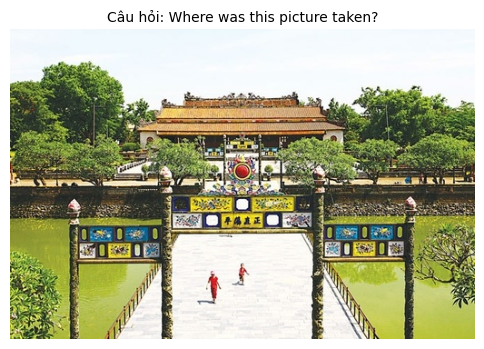

Đúng: Based on the visual features, this is Hall of Supreme Harmony (Citadel of Huế).
Dự đoán: This picture appears to be of the Hall of Supreme Harmony (Cung điện Thái Hòa) in the Imperial City of Huế, Vietnam. The Hall is one of the most important buildings in the complex and is known for its grand architecture and historical significance. The surrounding moat and the traditional Vietnamese gateways are also visible in the image.
--------------------------------------------------


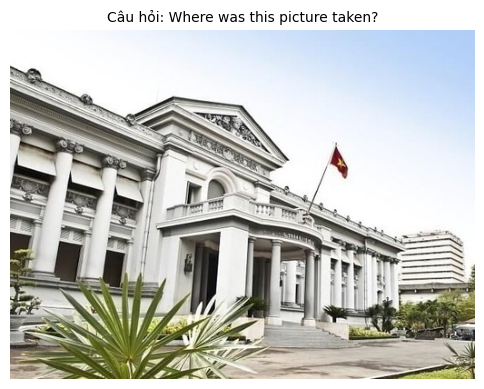

Đúng: Based on the visual features, this is Museum of Ho Chi Minh City.
Dự đoán: This picture appears to have been taken at the National Museum of Vietnamese History in Hanoi, Vietnam. The building is a prominent example of French colonial architecture and houses a significant collection of artifacts related to Vietnamese history.
--------------------------------------------------


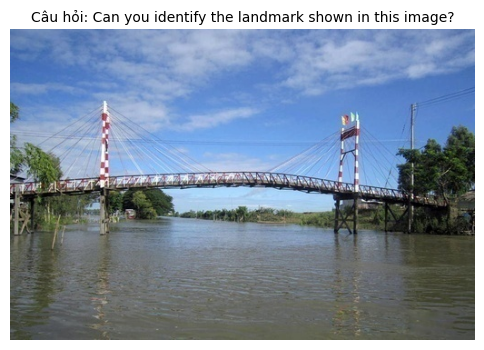

Đúng: Based on the visual features, this is Vĩnh Tế Canal.
Dự đoán: The landmark in the image is the Hoi An Cable-stayed Bridge, located in Hoi An, Vietnam. This bridge is known for its distinctive red and white striped cables and its unique design that allows it to span the Thu Bon River. The bridge is an important transportation link in the city and is a popular spot for both locals and tourists.
--------------------------------------------------


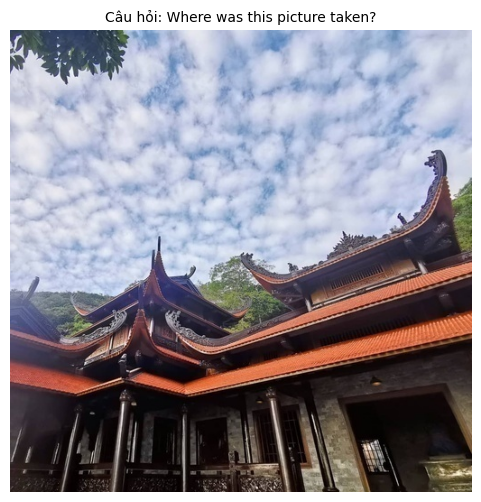

Đúng: Based on the visual features, this is Tà Cú.
Dự đoán: This picture appears to have been taken at the Temple of the Jade Mountain (Vinh Trang Pagoda) in Hanoi, Vietnam. The architecture and design of the buildings, particularly the red-tiled roofs and ornate wooden carvings, are characteristic of traditional Vietnamese temple architecture. The surrounding greenery and the mountainous background also align with the natural landscape of the area.
--------------------------------------------------


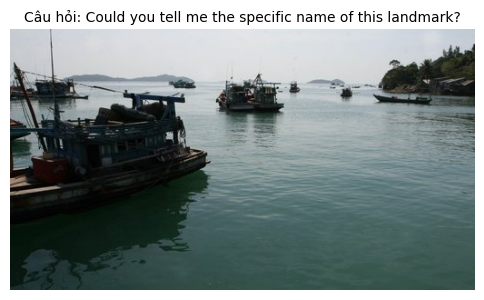

Đúng: Based on the visual features, this is Ha Tien Islands.
Dự đoán: The landmark in the picture is the "Bai Tu Long Bay" (Bay of the White Turtle) in Quang Ninh Province, Vietnam. Bai Tu Long Bay is known for its beautiful natural scenery and is a popular destination for tourists. The bay features a variety of islands, including Cat Ba Island, which is famous for its limestone caves and scenic landscapes. The image likely shows the entrance to the bay or a part of the bay with boats and islands.
--------------------------------------------------


In [41]:
import matplotlib.pyplot as plt
import random

# Số lượng mẫu muốn hiển thị
num_samples = 5

# Lấy mẫu ngẫu nhiên từ test_dataset
indices = random.sample(range(len(test_dataset)), min(num_samples, len(test_dataset)))

for idx in indices:
    sample = small_test_dataset[idx]
    image = sample["image_path"]
    question = sample["messages"][1]["content"][1]["text"]
    true_answer = get_ground_truth(sample)

    # Inference bằng fine‑tuned model
    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": question}
        ]}
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    ).to('cuda')

    with torch.no_grad():
        generated_ids = ft_model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    prediction = processor.batch_decode(generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0].strip()

    # Hiển thị ảnh và thông tin
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Câu hỏi: {question}", fontsize=10)
    plt.show()

    print(f"Đúng: {true_answer}")
    print(f"Dự đoán: {prediction}")
    print("-" * 50)